<b>Описание задачи</b>

Яндекс Недвижимость — маркетплейс для аренды и покупки жилой и коммерческой недвижимости. Компания играет роль посредника между арендодателями/продавцами и потенциальными арендаторами/покупателями. 

<b>Проблема</b>

Ключевая задача компании — сделать коммуникацию для обеих сторон эффективной и безопасной, ведь в процессе сделки появляется множество вопросов, которые могут перерасти в споры, и в итоге сделка не состоится. Для маркетплейса это невыгодный исход, поэтому продакт-менеджеры исследовали точки роста Яндекс Недвижимости и заметили, что часто разногласия возникают из-за цены на объект недвижимости. Всё дело в том, что у владельцев и покупателей представление о рыночной стоимости квартиры может быть разным — нужно помочь им договориться. 
Продакт-менеджеры выдвинули гипотезу, что среднемесячное количество сделок увеличится, если у сторон будет возможность провести объективную внешнюю оценку стоимости квартиры. 

<b>Бизнес-задача</b>

Ваша задача — разработать MVP алгоритма на основе машинного обучения для оценки рыночной стоимости квартиры по её характеристикам. Это означает, что нужно создать быстрое базовое решение, использовав наиболее распространённые и простые подходы к обработке данных и обучению модели.

<b>Задача машинного обучения</b>
    
Решите задачу регрессии по предсказанию цены на квартиру с помощью данных Яндекс Недвижимости.

<b>Данные</b>

В вашей персональной базе данных вы найдёте таблицы buildings и flats , в которых собраны данные для предсказания цен на квартиры:

- buildings — с данными о домах.
- flats — с данными о квартирах в этих домах.

<b>В таблице buildings есть следующие поля:</b>
- id — ID дома,
- build_year — год постройки,
- building_type_int — тип здания,
- latitude — широта, на которой находится дом,
- longitude — долгота, на которой находится дом,
- ceiling_height — высота потолков в здании,
- flats_count — общее количество квартир,
- floors_total — общее количество этажей,
- has_elevator — наличие лифта.

<b>В таблице flats хранится такая информация:</b>
- id — ID квартиры,
- building_id — ID дома, в котором находится квартира,
- floor — этаж, на котором находится квартира,
- kitchen_area — площадь кухни,
- living_area — площадь гостиной,
- rooms — количество комнат,
- is_apartment — является ли квартира апартаментами,
- studio — является ли квартира студией,
- total_area — общая площадь квартиры,
- price — цена квартиры.
Связь между таблицами осуществляется через колонку id в таблице buildings и колонку building_id в таблице flats.

### Откройте файл с данными и изучите общую информацию

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
data = pd.read_csv('flats.csv')
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141362 entries, 0 to 141361
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 141362 non-null  int64  
 1   build_year         141362 non-null  int64  
 2   building_type_int  141362 non-null  int64  
 3   latitude           141362 non-null  float64
 4   longitude          141362 non-null  float64
 5   ceiling_height     141362 non-null  float64
 6   flats_count        141362 non-null  int64  
 7   floors_total       141362 non-null  int64  
 8   has_elevator       141362 non-null  bool   
 9   building_id        141362 non-null  int64  
 10  floor              141362 non-null  int64  
 11  kitchen_area       141362 non-null  float64
 12  living_area        141362 non-null  float64
 13  rooms              141362 non-null  int64  
 14  is_apartment       141362 non-null  bool   
 15  studio             141362 non-null  bool   
 16  to

In [3]:
display(data.head())

,id,build_year,building_type_int,latitude,longitude,ceiling_height,flats_count,floors_total,has_elevator,building_id,floor,kitchen_area,living_area,rooms,is_apartment,studio,total_area,price
0,0,1965,6,55.717113,37.781120,2.64,84,12,True,6220,9,9.9,19.900000,1,False,False,35.099998,9500000
1,1,2001,2,55.794849,37.608013,3.00,97,10,True,18012,7,0.0,16.600000,1,False,False,43.000000,13500000
2,2,2000,4,55.740040,37.761742,2.70,80,10,True,17821,9,9.0,32.000000,2,False,False,56.000000,13500000
3,3,2002,4,55.672016,37.570877,2.64,771,17,True,18579,1,10.1,43.099998,3,False,False,76.000000,20000000
4,4,1971,1,55.808807,37.707306,2.60,208,9,True,9293,3,3.0,14.000000,1,False,False,24.000000,5200000


- Ошибок в типах данных (формате) не было обнаружено.
- Первичный вывод показал какие столбцы имеют числовые признаки. Следует провести анализ числовых признаков на наличие ошибок, пропусков и прочих аномалий. 

### Анализ целочисленных признаков

In [4]:
numeric_columns = [
    'build_year', 
    'building_type_int',
    'ceiling_height',
    'flats_count',
    'floors_total',
    'floor',
    'kitchen_area',
    'rooms',
    'total_area'
]

In [5]:
data[numeric_columns].describe()

,build_year,building_type_int,ceiling_height,flats_count,floors_total,floor,kitchen_area,rooms,total_area
count,141362.000000,141362.000000,141362.000000,141362.000000,141362.000000,141362.000000,141362.000000,141362.000000,141362.000000
mean,1986.600048,3.232941,2.753650,251.993230,14.107554,7.467346,9.001579,2.129476,62.374644
std,22.136409,1.459461,0.223275,207.336169,6.898045,5.717144,5.264076,0.994340,40.295864
min,1901.000000,0.000000,2.000000,1.000000,1.000000,1.000000,0.000000,1.000000,11.000000
25%,1969.000000,2.000000,2.640000,111.000000,9.000000,3.000000,6.100000,1.000000,39.299999
50%,1985.000000,4.000000,2.640000,200.000000,14.000000,6.000000,8.800000,2.000000,53.000000
75%,2007.000000,4.000000,2.800000,324.000000,17.000000,10.000000,10.200000,3.000000,72.000000
max,2023.000000,6.000000,27.000000,4455.000000,99.000000,56.000000,203.000000,20.000000,960.299988


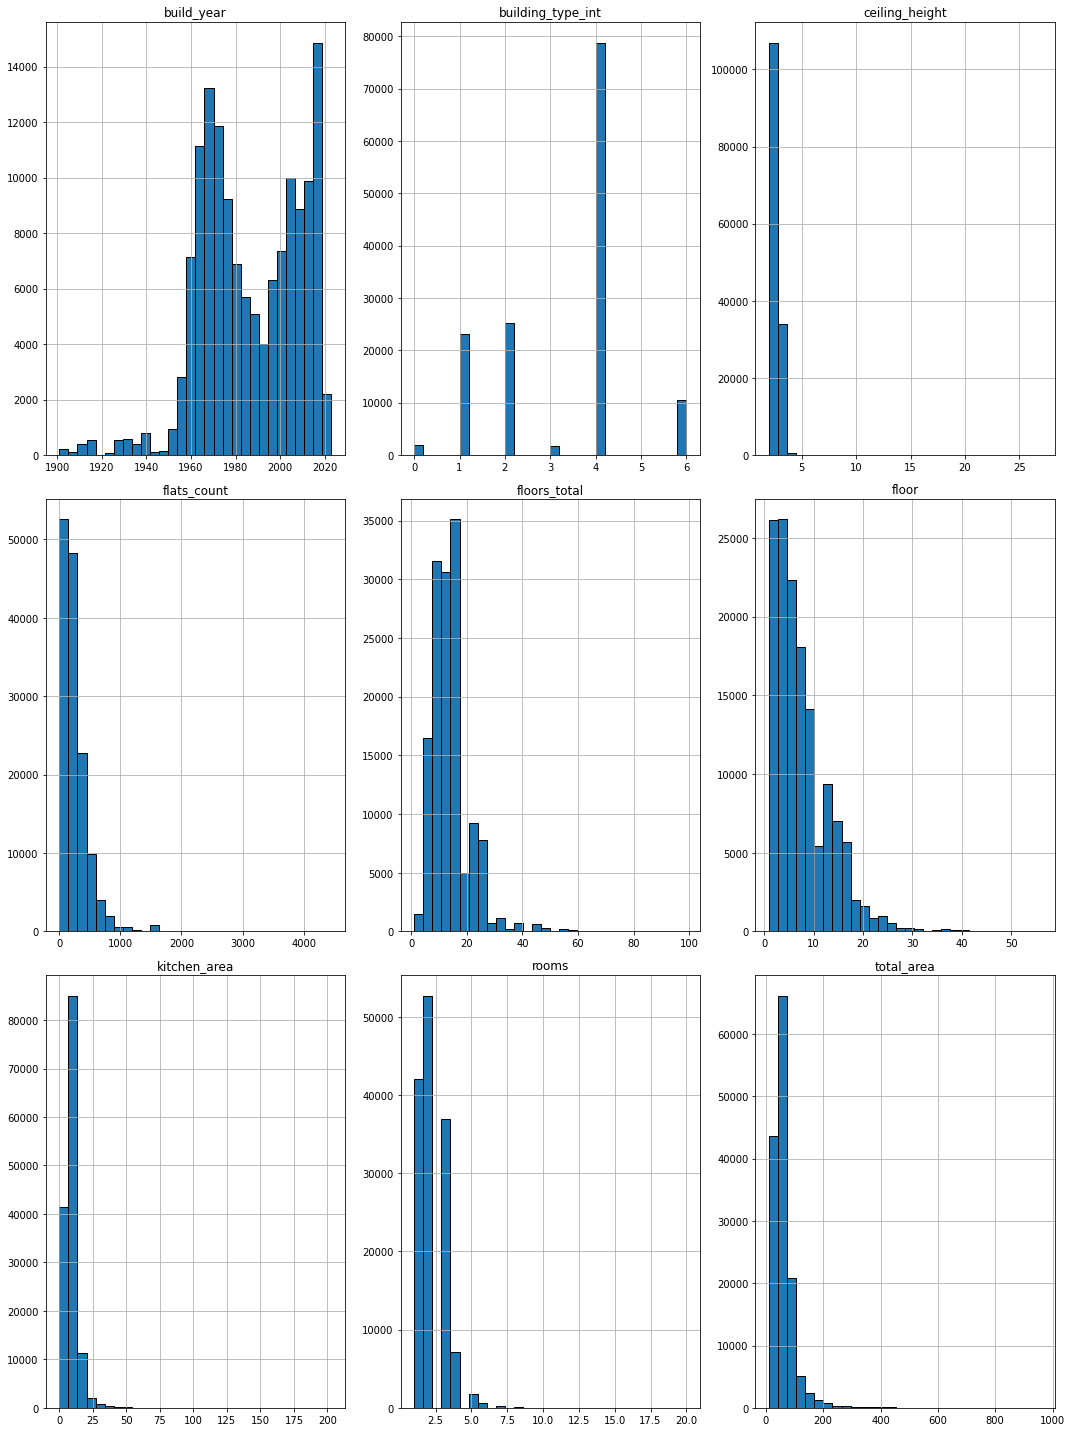

In [6]:
for column in numeric_columns:
    data[column] = pd.to_numeric(data[column], errors='coerce')

data[numeric_columns].hist(
    figsize=(15, 20),
    bins=30,
    edgecolor='black'
)

plt.tight_layout()
plt.show()

- Больше всего подозрений вызывают следующие признаки:ceiling_height (27 метров), flats_count (4455), floors_total (99), kitchen_area (203 м).   

In [7]:
numeric_columns = ['ceiling_height', 'flats_count', 'floors_total', 'kitchen_area']
for column in numeric_columns:
    print(f'\n{column}')
    print(data[column].sort_values(ascending=False).head(20).to_list())


ceiling_height
[27.0, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 7.0, 7.0, 7.0, 7.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0]

flats_count
[4455, 1630, 1630, 1630, 1630, 1630, 1630, 1630, 1630, 1630, 1630, 1630, 1630, 1630, 1630, 1630, 1630, 1630, 1630, 1630]

floors_total
[99, 81, 70, 66, 60, 59, 59, 59, 59, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58, 58]

kitchen_area
[203.0, 102.0, 100.0, 100.0, 100.0, 90.0, 87.0, 85.0, 83.4000015258789, 81.0, 80.0, 80.0, 80.0, 80.0, 80.0, 80.0, 78.0, 75.0, 75.0, 75.0]


In [8]:
data = data[
    (data['ceiling_height'].between(2, 5)) &
    (data['flats_count'].between(1, 2000)) &
    (data['floors_total'].between(1, 60)) &
    (data['kitchen_area'].between(0, 120))
].copy()

In [9]:
data = data[data['floor'] <= data['floors_total']]
data = data[data['kitchen_area'] <= data['total_area']]
data = data[data['rooms'] >= 1]
data = data[data['total_area'] >= data['kitchen_area']]

In [10]:
numeric_columns = [
    'build_year', 
    'building_type_int',
    'ceiling_height',
    'flats_count',
    'floors_total',
    'floor',
    'kitchen_area',
    'rooms',
    'total_area'
]
data[numeric_columns].describe()

,build_year,building_type_int,ceiling_height,flats_count,floors_total,floor,kitchen_area,rooms,total_area
count,141325.000000,141325.000000,141325.000000,141325.000000,141325.000000,141325.000000,141325.000000,141325.000000,141325.000000
mean,1986.611548,3.233271,2.752728,251.991389,14.107200,7.467589,8.998892,2.129121,62.353383
std,22.121012,1.459308,0.206674,206.972721,6.888774,5.717016,5.229753,0.993739,40.233103
min,1901.000000,0.000000,2.000000,1.000000,1.000000,1.000000,0.000000,1.000000,11.000000
25%,1969.000000,2.000000,2.640000,111.000000,9.000000,3.000000,6.100000,1.000000,39.299999
50%,1985.000000,4.000000,2.640000,200.000000,14.000000,6.000000,8.800000,2.000000,53.000000
75%,2007.000000,4.000000,2.800000,324.000000,17.000000,10.000000,10.200000,3.000000,72.000000
max,2023.000000,6.000000,5.000000,1630.000000,60.000000,56.000000,100.000000,20.000000,960.299988


<b>Вывод</b>
- Были удалены аномальные значения которые вероятно навредили бы точности модели машинного обучения.
- Удалены невозможные/ошибочные значения которые могут также навредить точности МО. К примеру отрицальные значения или когда комната в квартире больше общей площади.

### Анализ целевого признака (price)

In [11]:
print(data['price'].describe().apply(lambda x: f'{x:,.0f}'))

count          141,325
mean        19,433,481
std         66,270,202
min                 11
25%          8,900,000
50%         11,850,000
75%         16,950,000
max      9,873,737,728
Name: price, dtype: object


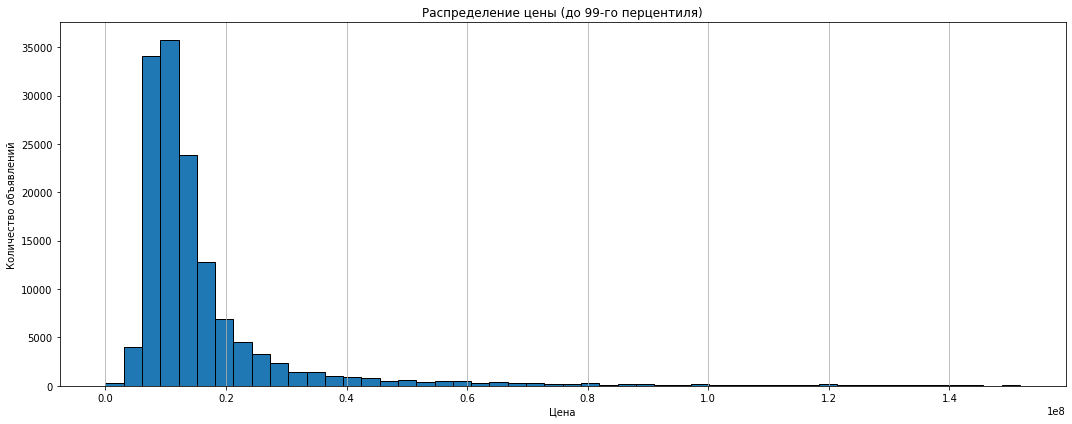

In [12]:
price_99 = data['price'].quantile(0.99)

data[data['price'] <= price_99]['price'].hist(
    figsize=(15, 6),
    bins=50,
    edgecolor='black'
)

plt.xlabel('Цена')
plt.ylabel('Количество объявлений')
plt.title('Распределение цены (до 99-го перцентиля)')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
data.sort_values('price', ascending=False)[
    ['price', 'total_area', 'rooms', 'build_year']
].head(20)

,price,total_area,rooms,build_year
85787,9873737728,220.000000,5,2006
83773,9799999488,37.000000,2,1965
40855,9200000000,45.000000,2,1974
118083,8147034112,208.000000,4,2012
50455,4686425088,103.000000,3,2013
79266,4447152128,120.000000,4,2009
58778,4048056064,202.000000,7,1912
79264,3525904640,97.000000,3,2017
14433,2551801088,925.000000,10,2009
115280,2551801088,925.000000,10,2009


In [14]:
data.sort_values('price', ascending=True)[
    ['price', 'total_area', 'rooms', 'build_year']
].head(20)

,price,total_area,rooms,build_year
69633,11,42.000000,2,2007
107198,19,70.000000,2,1972
104573,85,59.000000,1,1964
60417,1500,36.000000,1,2012
76800,2000,38.000000,1,1966
128961,2000,40.000000,1,2007
61931,2000,30.000000,1,1960
126489,2300,38.200001,1,1978
137162,2400,40.000000,1,1966
59840,2500,36.000000,1,1983


- В целевом признаке аномалии не однозначны, к примеру: недвижимость стоит 9,8 млрд при площади 37 кв.метров и двух комнатах что явно похоже на ошибку, но есть к примеру и вполне реальные значения 9,8 млрд при площади 220 кв.метров.
- Решением будет разделить price на total_area что бы получить цену за квадрат и уже дальше удалить заоблачные значения.

In [15]:
data['price_per_m2'] = data['price'] / data['total_area']

print(data['price_per_m2'].describe().apply(lambda x: f'{x:,.0f}'))

display(
    data.sort_values('price_per_m2', ascending=False)[
        ['price', 'total_area', 'price_per_m2', 'rooms', 'build_year']
    ].head(20)
)

count        141,325
mean         269,309
std          942,303
min                0
25%          191,348
50%          233,333
75%          288,425
max      264,864,851
Name: price_per_m2, dtype: object


,price,total_area,price_per_m2,rooms,build_year
83773,9799999488,37.000000,2.648649e+08,2,1965
40855,9200000000,45.000000,2.044444e+08,2,1974
50455,4686425088,103.000000,4.549927e+07,3,2013
85787,9873737728,220.000000,4.488063e+07,5,2006
118083,8147034112,208.000000,3.916843e+07,4,2012
79266,4447152128,120.000000,3.705960e+07,4,2009
79264,3525904640,97.000000,3.634953e+07,3,2017
37521,2500000000,84.000000,2.976190e+07,3,1996
58778,4048056064,202.000000,2.003988e+07,7,1912
55967,1174683008,61.000000,1.925710e+07,3,2020


In [16]:
print('500 тыс. – 1 млн:',
      data['price_per_m2'].between(500_000, 1_000_000).sum())

print('1 млн – 5 млн:',
      data['price_per_m2'].between(1_000_000, 5_000_000).sum())

print('5 млн – 10 млн:',
      data['price_per_m2'].between(5_000_000, 10_000_000).sum())

print('Более 10 млн:',
      (data['price_per_m2'] > 10_000_000).sum())

500 тыс. – 1 млн: 5152
1 млн – 5 млн: 934
5 млн – 10 млн: 3
Более 10 млн: 15


In [17]:
print(
    '0–10 тыс.:',
    (data['price_per_m2'] < 10_000).sum()
)

print(
    '10–50 тыс.:',
    data['price_per_m2'].between(10_000, 50_000, inclusive='left').sum()
)

print(
    '50–100 тыс.:',
    data['price_per_m2'].between(50_000, 100_000, inclusive='left').sum()
)

print(
    '100–150 тыс.:',
    data['price_per_m2'].between(100_000, 150_000, inclusive='left').sum())

0–10 тыс.: 152
10–50 тыс.: 46
50–100 тыс.: 460
100–150 тыс.: 8057


- В предоставленных данных есть недвижимость действительно дорогая, если считать по стоимости кв.метра то лучше оставить значения до 5 млн за метр.
- Аналогично поступим и с аномально низкими ценами на жилье, все что дешевле 50 тыс за кв.метр удалим.

### Удаление выбросов целевого признака

In [18]:
#data = data[
#    (data['price_per_m2'] >= 50_000) &
#    (data['price_per_m2'] <= 1_000_000)
#].copy()
#data = data.drop(columns='price_per_m2')

In [19]:
before = len(data)

data['price_per_m2'] = data['price'] / data['total_area']

data = data[
    (data['price_per_m2'] >= 50_000) &
    (data['price_per_m2'] <= 1_000_000)
].copy()
data = data.drop(columns='price_per_m2')
after = len(data)

removed = before - after
removed_percent = removed / before * 100

print(f'Было записей: {before:,}')
print(f'Стало записей: {after:,}')
print(f'Удалено записей: {removed:,}')
print(f'Удалено: {removed_percent:.2f}%')
print(f'Осталось: {(after / before * 100):.2f}%')

Было записей: 141,325
Стало записей: 140,199
Удалено записей: 1,126
Удалено: 0.80%
Осталось: 99.20%


## Вывод

Было удалены ценовые аномалии, которые могли бы уменьшить точность модели МО по предсказанию цены жилья. Всего удалено 0.8% записей.